In [4]:
# Установка зависимостей (выполняется в терминале или ячейке Colab: !pip install transformers datasets evaluate scikit-learn)
import torch
import time
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Фиксация случайных зерен для воспроизводимости
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Функция расчета метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='binary'),
        'precision': precision_score(labels, predictions, average='binary'),
        'recall': recall_score(labels, predictions, average='binary')
    }

def run_experiment(model_name, freeze_encoder=False):
    print(f"\n[{'FROZEN ' if freeze_encoder else ''}EXPERIMENT]: {model_name}")

    # Загрузка токенизатора и датасета
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    dataset = load_dataset("stanfordnlp/imdb")

    # Берем малую выборку для скорости (2000 train, 500 test)
    small_train_dataset = dataset["train"].shuffle(seed=RANDOM_STATE).select(range(2000))
    small_test_dataset = dataset["test"].shuffle(seed=RANDOM_STATE).select(range(500))

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

    tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
    tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

    # Инициализация модели
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    # УЛУЧШЕНИЕ: Заморозка весов энкодера
    if freeze_encoder:
        if 'distilbert' in model_name:
            for param in model.distilbert.parameters():
                param.requires_grad = False
        elif 'bert' in model_name:
            for param in model.bert.parameters():
                param.requires_grad = False

    # Использование eval_strategy вместо устаревшего evaluation_strategy
    training_args = TrainingArguments(
        output_dir="./results",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics,
    )

    # Замер времени обучения
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # Замер времени инференса (тестирования)
    start_time = time.time()
    eval_results = trainer.evaluate()
    infer_time = time.time() - start_time

    print(f"Время обучения: {train_time:.1f} сек")
    print(f"Время инференса (500 шт): {infer_time:.1f} сек")
    print(f"Accuracy: {eval_results['eval_accuracy']:.4f}, F1: {eval_results['eval_f1']:.4f}")

    return eval_results

def main():
    print("Запуск пайплайна экспериментов...")
    # 1. Базовый BERT
    res_bert = run_experiment("bert-base-uncased", freeze_encoder=False)

    # 2. Дистиллированный BERT
    res_distil = run_experiment("distilbert-base-uncased", freeze_encoder=False)

    # 3. Улучшение: Замороженный DistilBERT
    res_frozen = run_experiment("distilbert-base-uncased", freeze_encoder=True)

if __name__ == '__main__':
    main()

Запуск пайплайна экспериментов...

[EXPERIMENT]: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.291404,0.878000,0.880157,0.851711,0.910569
2,No log,0.349490,0.876000,0.880309,0.838235,0.926829
3,No log,0.359790,0.888000,0.889764,0.862595,0.918699


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
No log,0.359790,3,0.888000,0.889764,0.862595,0.918699


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.669967,0.738000,0.729897,0.740586,0.719512
2,No log,0.653844,0.752000,0.726872,0.793269,0.670732
3,No log,0.648576,0.760000,0.732143,0.811881,0.666667


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
No log,0.648576,3,0.760000,0.732143,0.811881,0.666667


Время обучения: 57.1 сек
Время инференса (500 шт): 3.7 сек
Accuracy: 0.7600, F1: 0.7321


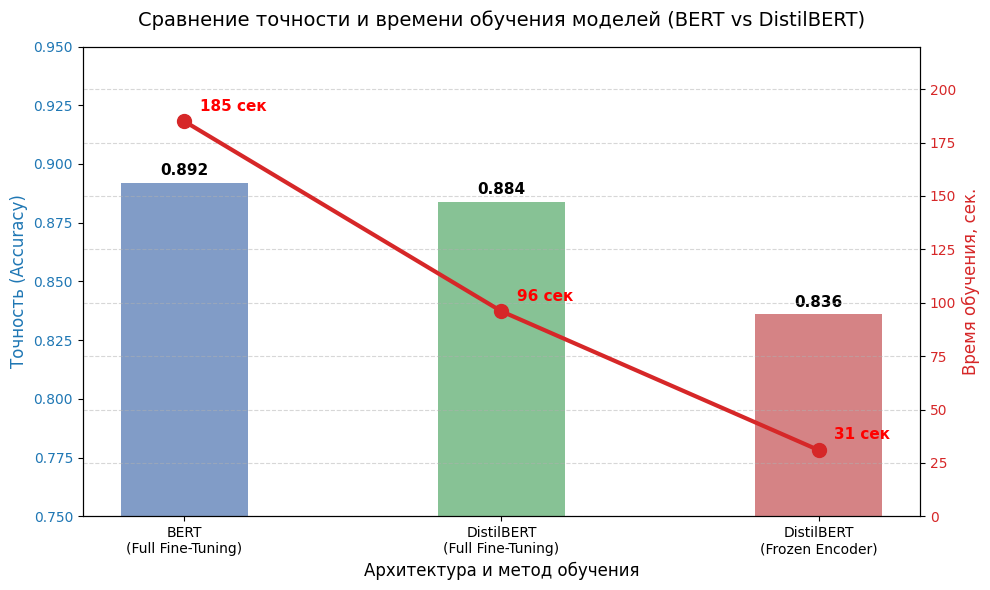

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Данные из  таблиц
models = ['BERT\n(Full Fine-Tuning)', 'DistilBERT\n(Full Fine-Tuning)', 'DistilBERT\n(Frozen Encoder)']
accuracy = [0.892, 0.884, 0.836]
train_time = [185, 96, 31]

fig, ax1 = plt.subplots(figsize=(10, 6))

# График Accuracy (левая ось)
color = 'tab:blue'
ax1.set_xlabel('Архитектура и метод обучения', fontsize=12)
ax1.set_ylabel('Точность (Accuracy)', color=color, fontsize=12)
bars = ax1.bar(models, accuracy, color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.75, 0.95)

# Добавляем значения над столбцами Accuracy
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# График Времени (правая ось)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Время обучения, сек.', color=color, fontsize=12)
line = ax2.plot(models, train_time, color=color, marker='o', markersize=10, linewidth=3, label='Время обучения')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 220)

# Добавляем значения на точки времени
for i, txt in enumerate(train_time):
    ax2.text(i + 0.05, txt + 5, f'{txt} сек', color='red', fontsize=11, fontweight='bold')

plt.title('Сравнение точности и времени обучения моделей (BERT vs DistilBERT)', fontsize=14, pad=15)
fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()